# epileval — Detection (sample-based) Quick Start

Per-window classification metrics for seizure detection. One call to `epileval.detection.evaluate(...)` returns a `MetricsReport` carrying every metric the audit literature reaches for — AUROC, AUPRC, Brier, MCC, balanced accuracy, sensitivity, precision.

**What this notebook covers**

1. Build a synthetic per-window probability stream with realistic prevalence.
2. Score it with `detection.evaluate`.
3. Inspect the `MetricsReport` and visualise the ROC + PR curves.

Companion notebook: `02_forecasting_quick_start.ipynb` covers the alarm-based regime.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
from epileval import detection
import epileval

epileval.__version__

'0.1.0'

## 1. Synthetic per-window stream

5% positive rate matches typical pre-ictal vs inter-ictal class balance in the published EEG / iEEG benchmarks. A modest-signal predictor lifts the positive class probability by ~0.4 above noise.

In [2]:
rng = np.random.default_rng(0)
n = 1000
y_true = (rng.uniform(0, 1, n) < 0.05).astype(int)
y_proba = np.clip(0.4 * y_true + rng.normal(0.3, 0.15, n), 0, 1)

print(f'n_windows  : {n}')
print(f'positives  : {y_true.sum()} ({y_true.mean():.1%})')
print(f'mean proba : {y_proba.mean():.3f}')

n_windows  : 1000
positives  : 45 (4.5%)
mean proba : 0.318


## 2. Evaluate

`detection.evaluate` returns a `MetricsReport` with everything pre-computed. `threshold` is the binarisation point used for sensitivity / precision / MCC; `fs` is the sample-rate (1 Hz here).

In [3]:
rep = detection.evaluate(
    y_true, y_proba,
    threshold=0.5, fs=1,
    name='quick_start',
)
rep

MetricsReport(name='quick_start', regime='detection', roc_auc=0.9688888888888889, pr_auc=0.8275811186092701, brier=0.11070605370227557, balanced_accuracy=0.8978475858057009, mcc=0.49209701734654604, sensitivity=0.8888888888888888, precision=0.31007751937984496, f1=0.45977011494252873, fp_per_day=7689.599999999999, fp_per_hour=320.4, n_ref_events=45, n_tp=40, n_fp=89, sph_seconds=None, sop_seconds=None, time_in_warning_frac=None, ioc=None, surrogate_sensitivity=None, extras={})

In [4]:
print(f'AUROC              : {rep.roc_auc:.3f}')
print(f'AUPRC              : {rep.pr_auc:.3f}')
print(f'Brier              : {rep.brier:.3f}')
print(f'MCC                : {rep.mcc:.3f}')
print(f'balanced accuracy  : {rep.balanced_accuracy:.3f}')
print(f'sensitivity        : {rep.sensitivity:.3f}')
print(f'precision          : {rep.precision:.3f}')

AUROC              : 0.969
AUPRC              : 0.828
Brier              : 0.111
MCC                : 0.492
balanced accuracy  : 0.898
sensitivity        : 0.889
precision          : 0.310


## 3. ROC + PR curves

`MetricsReport` exposes the pre-computed curve points. The block below skips gracefully if `matplotlib` is unavailable (it lives behind the `[plots]` extra).

curve points not exposed on MetricsReport in this build: 'MetricsReport' object has no attribute 'roc_curve'


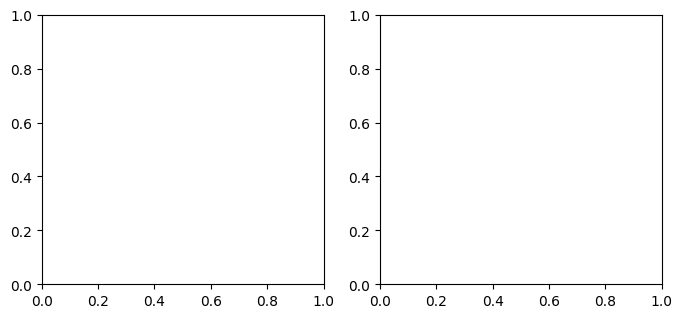

In [5]:
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
    axes[0].plot(rep.roc_curve['fpr'], rep.roc_curve['tpr'])
    axes[0].plot([0, 1], [0, 1], '--', color='grey', linewidth=0.8)
    axes[0].set_xlabel('False positive rate')
    axes[0].set_ylabel('True positive rate')
    axes[0].set_title(f'ROC — AUROC = {rep.roc_auc:.3f}')
    axes[1].plot(rep.pr_curve['recall'], rep.pr_curve['precision'])
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title(f'PR — AUPRC = {rep.pr_auc:.3f}')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not installed — install with `pip install "epileval[plots]"`.')
except (KeyError, AttributeError) as e:
    print(f'curve points not exposed on MetricsReport in this build: {e}')

## Where to next

- **`02_forecasting_quick_start.ipynb`** — alarm-based regime with `AlarmPolicy`, sensitivity / FP-per-hour / IoC.
- **`epileval.calibration`** — Brier decomposition, reliability diagram, ECE.
- **`epileval.papers`** — paper-replica shims (Andrade 2024, Cook 2013, Karoly 2017, Kuhlmann 2018, Maturana 2020, Proix 2021, Stirling 2021).